<a href="https://colab.research.google.com/github/2303A51908/Reinforecement-Learning---B12/blob/main/2303A51908_RL_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Episode 010 | Reward 36.0 | Mean(10): 17.90
Episode 020 | Reward 33.0 | Mean(10): 33.50
Episode 030 | Reward 30.0 | Mean(10): 25.00
Episode 040 | Reward 16.0 | Mean(10): 16.70
Episode 050 | Reward 33.0 | Mean(10): 22.70
Episode 060 | Reward 9.0 | Mean(10): 18.00
Episode 070 | Reward 10.0 | Mean(10): 16.20
Episode 080 | Reward 14.0 | Mean(10): 15.30
Episode 090 | Reward 17.0 | Mean(10): 14.30
Episode 100 | Reward 10.0 | Mean(10): 13.20
Episode 110 | Reward 10.0 | Mean(10): 13.90
Episode 120 | Reward 21.0 | Mean(10): 20.30
Episode 130 | Reward 31.0 | Mean(10): 15.50
Episode 140 | Reward 15.0 | Mean(10): 11.60
Episode 150 | Reward 26.0 | Mean(10): 15.20
Episode 160 | Reward 9.0 | Mean(10): 17.70
Episode 170 | Reward 12.0 | Mean(10): 14.50
Episode 180 | Reward 11.0 | Mean(10): 15.80
Episode 190 | Reward 29.0 | Mean(10): 18.80
Episode 200 | Reward 9.0 | Mean(10): 15.50


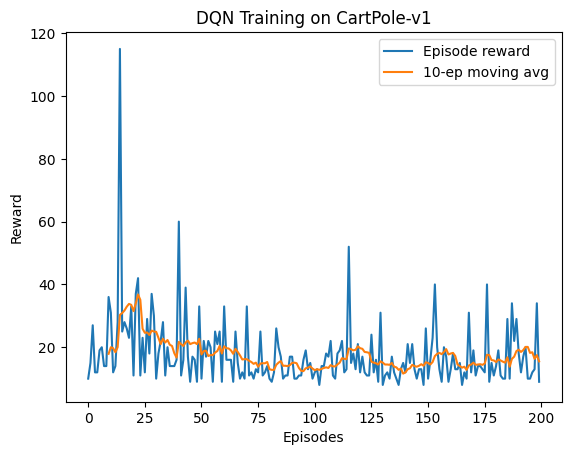

In [1]:
import random, math, collections, time
from collections import deque
import numpy as np
import torch, torch.nn as nn, torch.optim as optim
import gymnasium as gym
import matplotlib.pyplot as plt

Transition = collections.namedtuple('Transition', ('state','action','reward','next_state','done'))

class ReplayBuffer:
    def __init__(self, capacity): self.buffer = deque(maxlen=capacity)
    def push(self,*args): self.buffer.append(Transition(*args))
    def sample(self,batch_size): return Transition(*zip(*random.sample(self.buffer,batch_size)))
    def __len__(self): return len(self.buffer)

class QNet(nn.Module):
    def __init__(self, obs_size, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_size,128), nn.ReLU(),
            nn.Linear(128,128), nn.ReLU(),
            nn.Linear(128,n_actions))
    def forward(self,x): return self.net(x.float())

def select_action(net,state,epsilon,n_actions,device):
    if random.random()<epsilon: return random.randrange(n_actions)
    state_v=torch.tensor(state,dtype=torch.float32).to(device).unsqueeze(0)
    q_vals=net(state_v); _,act_v=torch.max(q_vals,dim=1)
    return int(act_v.item())

def compute_loss(batch,net,target_net,gamma,device):
    states=torch.tensor(np.array(batch.state),dtype=torch.float32).to(device)
    actions=torch.tensor(batch.action,dtype=torch.long).to(device).unsqueeze(1)
    rewards=torch.tensor(batch.reward,dtype=torch.float32).to(device).unsqueeze(1)
    next_states=torch.tensor(np.array(batch.next_state),dtype=torch.float32).to(device)
    dones=torch.tensor(batch.done,dtype=torch.float32).to(device).unsqueeze(1)

    q_values=net(states).gather(1,actions)
    with torch.no_grad():
        next_q=target_net(next_states).max(1)[0].unsqueeze(1)
        target_q=rewards+gamma*next_q*(1-dones)
    return nn.functional.mse_loss(q_values,target_q)

def train_dqn(env_name='CartPole-v1', episodes=200):
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
    env=gym.make(env_name); env.reset(seed=42)
    obs_size=env.observation_space.shape[0]; n_actions=env.action_space.n

    net, target_net=QNet(obs_size,n_actions).to(device), QNet(obs_size,n_actions).to(device)
    target_net.load_state_dict(net.state_dict())
    buffer=ReplayBuffer(10000)
    optimizer=optim.Adam(net.parameters(),lr=1e-3)

    gamma=0.99; batch_size=64
    sync_target_frames=1000; replay_start_size=1000
    eps_start,eps_final,eps_decay=1.0,0.02,5000
    total_steps=0; rewards=[]

    for ep in range(1,episodes+1):
        state,_=env.reset(); done=False; ep_reward=0
        while not done:
            eps=eps_final+(eps_start-eps_final)*math.exp(-1.0*total_steps/eps_decay)
            action=select_action(net,state,eps,n_actions,device)
            next_state,reward,terminated,truncated,_=env.step(action)
            done=terminated or truncated
            buffer.push(state,action,reward,next_state,float(done))
            state=next_state; ep_reward+=reward; total_steps+=1

            if len(buffer)>=replay_start_size:
                batch=buffer.sample(batch_size)
                loss=compute_loss(batch,net,target_net,gamma,device)
                optimizer.zero_grad(); loss.backward(); optimizer.step()

            if total_steps%sync_target_frames==0:
                target_net.load_state_dict(net.state_dict())

        rewards.append(ep_reward)
        if ep%10==0: print(f"Episode {ep:03d} | Reward {ep_reward:.1f} | Mean(10): {np.mean(rewards[-10:]):.2f}")

        if len(rewards)>=20 and np.mean(rewards[-20:])>=195:
            print(f"Solved in {ep} episodes!")
            break

    env.close()
    plt.plot(rewards,label="Episode reward")
    window=10
    if len(rewards)>=window:
        moving_avg=np.convolve(rewards,np.ones(window)/window,mode="valid")
        plt.plot(range(window-1,len(rewards)),moving_avg,label=f"{window}-ep moving avg")
    plt.xlabel("Episodes"); plt.ylabel("Reward"); plt.legend(); plt.title("DQN Training on CartPole-v1")
    plt.show()

if __name__=="__main__":
    train_dqn(episodes=200)
